In [ ]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "jupyter_notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")


In [1]:
from collections import defaultdict
from pathlib import Path
import pickle
from html import escape

import matplotlib.pyplot as plt
import numpy as np
import spacy
import torch
from IPython.display import HTML, display
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from spacy.tokenizer import Tokenizer
from spacy.util import compile_infix_regex
from transformers import AutoModel, AutoTokenizer

from text_processing import (
    clean_text,
    encode_chunk_batch,
    extract_important_spans,
    get_token_indices_for_phrase,
    normalize_text,
)
from utils import build_hotpot_retrieval_dataset, hdbscan_cluster
from wordnet_explorer import WordNetExplorer

In [2]:
hotpot_file_candidates = [
    REPO_ROOT / "jupyter_notebooks" / "hotpot_dev_distractor_v1.json",
    REPO_ROOT / "hotpot_dev_distractor_v1.json",
]
file_path = next((str(path) for path in hotpot_file_candidates if path.exists()), str(hotpot_file_candidates[0]))
print(f"Using HotpotQA file: {file_path}")
num_samples = None

spacy_model_name = "en_core_web_lg"
text_encoder_name_or_path = "/home/xiaoyue/ProtoGraphRAG/deberta-v3-large"


device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 8
remove_duplicate_token = True
discard_no_word = False

sample_tag = "all" if num_samples is None else str(num_samples)
output_path = Path(f"hotpot_phrase_token_embedding_index_{sample_tag}.pkl")

In [3]:
nlp = None
tokenizer = None
text_encoder = None


def load_custom_nlp(model_name: str):
    loaded_nlp = spacy.load(model_name)
    infixes = [pattern for pattern in loaded_nlp.Defaults.infixes if "-" not in pattern]
    infix_re = compile_infix_regex(infixes)

    loaded_nlp.tokenizer = Tokenizer(
        loaded_nlp.vocab,
        prefix_search=loaded_nlp.tokenizer.prefix_search,
        suffix_search=loaded_nlp.tokenizer.suffix_search,
        infix_finditer=infix_re.finditer,
        token_match=loaded_nlp.tokenizer.token_match,
    )
    return loaded_nlp


def load_text_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        fix_mistral_regex=True,
        use_fast=True,
    )
    if not getattr(loaded_tokenizer, "is_fast", False):
        raise TypeError("encode_chunk_batch requires a fast tokenizer because it uses return_offset_mapping=True")

    loaded_text_encoder = AutoModel.from_pretrained(
        name_or_path,
        local_files_only=True,
    )
    loaded_text_encoder.to(device)
    loaded_text_encoder.eval()
    return loaded_tokenizer, loaded_text_encoder


def ensure_nlp_loaded():
    global nlp
    if nlp is None:
        nlp = load_custom_nlp(spacy_model_name)
        print(f"Loaded spaCy model: {spacy_model_name}")
    return nlp


def ensure_text_encoder_loaded():
    global tokenizer, text_encoder
    if tokenizer is None or text_encoder is None:
        tokenizer, text_encoder = load_text_encoder(text_encoder_name_or_path, device)
        print(f"Loaded text encoder on {device}")
    return tokenizer, text_encoder


if output_path.exists():
    print(f"Found cache at {output_path}. Hotpot index rebuild will be skipped.")
else:
    ensure_nlp_loaded()
    ensure_text_encoder_loaded()

Found cache at hotpot_phrase_token_embedding_index_all.pkl. Hotpot index rebuild will be skipped.


In [4]:
if output_path.exists():
    documents = None
    samples = None
    print(f"Found cache at {output_path}. Skip Hotpot dataset loading.")
else:
    documents, samples = build_hotpot_retrieval_dataset(file_path, num_samples=num_samples)
    print(f"documents: {len(documents)}")
    print(f"samples: {len(samples)}")
    documents[0]

Found cache at hotpot_phrase_token_embedding_index_all.pkl. Skip Hotpot dataset loading.


In [5]:
def collect_span_embedding_records(token_embeddings, offsets, span_list, kind, document_idx, title):
    records = []
    for term, start_char, end_char in span_list:
        token_indices = get_token_indices_for_phrase(start_char, end_char, offsets)
        if not token_indices:
            continue

        embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
        records.append(
            {
                "kind": kind,
                "term": term,
                "document_idx": int(document_idx),
                "title": title,
                "span": (int(start_char), int(end_char)),
                "embedding": embedding,
            }
        )
    return records


def build_phrase_token_embedding_index(
    documents,
    nlp,
    text_encoder,
    tokenizer,
    device,
    batch_size=8,
    remove_duplicate_token=True,
    discard_no_word=False,
):
    cleaned_documents = [clean_text(doc["text"]) for doc in documents]

    store = {
        "documents": documents,
        "cleaned_documents": cleaned_documents,
        "index": defaultdict(list),
        "config": {
            "batch_size": batch_size,
            "remove_duplicate_token": remove_duplicate_token,
            "discard_no_word": discard_no_word,
            "encoder": text_encoder.__class__.__name__,
            "tokenizer": tokenizer.__class__.__name__,
            "device": device,
            "text_encoder_name_or_path": text_encoder_name_or_path,
            "spacy_model_name": spacy_model_name,
        },
    }

    phrase_occurrences = 0
    token_occurrences = 0
    total_documents = len(documents)
    progress_handle = display(f"Processed 0/{total_documents} documents", display_id=True)

    for batch_start in range(0, total_documents, batch_size):
        batch_end = min(batch_start + batch_size, total_documents)
        batch_docs = documents[batch_start:batch_end]
        batch_texts = [cleaned_documents[idx] for idx in range(batch_start, batch_end)]

        batch_spans = [
            extract_important_spans(
                text,
                nlp,
                min_tokens=2,
                remove_duplicate=remove_duplicate_token,
                discard_no_word=discard_no_word,
            )
            for text in batch_texts
        ]

        token_embeddings_batch, offsets_batch = encode_chunk_batch(
            batch_texts,
            text_encoder,
            tokenizer,
            device,
        )

        for local_idx, ((phrases, tokens), token_embeddings, offsets) in enumerate(
            zip(batch_spans, token_embeddings_batch, offsets_batch)
        ):
            document_idx = batch_start + local_idx
            title = batch_docs[local_idx]["title"]

            phrase_records = collect_span_embedding_records(
                token_embeddings,
                offsets,
                phrases,
                kind="phrase",
                document_idx=document_idx,
                title=title,
            )
            token_records = collect_span_embedding_records(
                token_embeddings,
                offsets,
                tokens,
                kind="token",
                document_idx=document_idx,
                title=title,
            )

            for record in phrase_records:
                store["index"][record["term"]].append(record)
            for record in token_records:
                store["index"][record["term"]].append(record)

            phrase_occurrences += len(phrase_records)
            token_occurrences += len(token_records)

        progress_handle.update(f"Processed {batch_end}/{total_documents} documents")

    store["stats"] = {
        "num_documents": len(documents),
        "num_unique_terms": len(store["index"]),
        "num_phrase_occurrences": phrase_occurrences,
        "num_token_occurrences": token_occurrences,
        "num_total_occurrences": phrase_occurrences + token_occurrences,
    }
    return store


def lookup_embeddings(store, query_text, kind=None, include_text=True, include_cleaned_text=True):
    normalized_query = normalize_text(query_text.strip())
    records = list(store["index"].get(normalized_query, []))

    if kind is not None:
        records = [record for record in records if record["kind"] == kind]

    if not include_text and not include_cleaned_text:
        return records

    enriched_records = []
    for record in records:
        item = dict(record)
        document_idx = item["document_idx"]
        if include_text:
            item["text"] = store["documents"][document_idx]["text"]
        if include_cleaned_text:
            item["cleaned_text"] = store["cleaned_documents"][document_idx]
        enriched_records.append(item)
    return enriched_records


def get_document(store, document_idx):
    return store["documents"][document_idx]


def _scatter_by_kind(coords, records, title, xlabel, ylabel, annotate=False):
    color_map = {"phrase": "tab:blue", "token": "tab:orange"}
    plt.figure(figsize=(8, 6))

    for current_kind in ["phrase", "token"]:
        indices = [idx for idx, record in enumerate(records) if record["kind"] == current_kind]
        if not indices:
            continue
        plt.scatter(
            coords[indices, 0],
            coords[indices, 1],
            s=45,
            alpha=0.75,
            c=color_map[current_kind],
            label=current_kind,
        )

    if annotate:
        for idx, record in enumerate(records):
            plt.annotate(
                f"{record['kind']}:{record['document_idx']}",
                (coords[idx, 0], coords[idx, 1]),
                fontsize=8,
                alpha=0.8,
            )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def _scatter_by_cluster(coords, records, title, xlabel, ylabel, annotate=False):
    unique_labels = sorted({record["cluster_label"] for record in records if record["cluster_label"] != -1})
    color_map = plt.get_cmap("tab20", max(1, len(unique_labels)))
    plt.figure(figsize=(8, 6))

    for color_idx, label in enumerate(unique_labels):
        indices = [idx for idx, record in enumerate(records) if record["cluster_label"] == label]
        if not indices:
            continue
        plt.scatter(
            coords[indices, 0],
            coords[indices, 1],
            s=45,
            alpha=0.75,
            color=color_map(color_idx),
            label=f"cluster {label}",
        )

    noise_indices = [idx for idx, record in enumerate(records) if record["cluster_label"] == -1]
    if noise_indices:
        plt.scatter(
            coords[noise_indices, 0],
            coords[noise_indices, 1],
            s=45,
            alpha=0.55,
            color="lightgray",
            label="noise",
        )

    if annotate:
        for idx, record in enumerate(records):
            label = "noise" if record["cluster_label"] == -1 else f"c{record['cluster_label']}"
            plt.annotate(
                f"{label}:{record['document_idx']}",
                (coords[idx, 0], coords[idx, 1]),
                fontsize=8,
                alpha=0.8,
            )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def plot_term_embeddings(store, query_text, kind=None, perplexity=30, random_state=42, annotate=False):
    records = lookup_embeddings(
        store,
        query_text,
        kind=kind,
        include_text=False,
        include_cleaned_text=False,
    )

    if not records:
        print(f"No records found for {query_text!r}")
        return None

    if len(records) < 2:
        print(f"Only {len(records)} record found for {query_text!r}; at least 2 are required for visualization.")
        return {"records": records}

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    normalized_query = normalize_text(query_text.strip())

    pca_coords = PCA(n_components=2).fit_transform(embeddings)
    _scatter_by_kind(
        pca_coords,
        records,
        title=f"PCA projection for '{normalized_query}' ({len(records)} records)",
        xlabel="PC1",
        ylabel="PC2",
        annotate=annotate,
    )

    tsne_perplexity = min(perplexity, len(records) - 1)
    tsne_coords = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(embeddings)
    _scatter_by_kind(
        tsne_coords,
        records,
        title=f"t-SNE projection for '{normalized_query}' ({len(records)} records, perplexity={tsne_perplexity})",
        xlabel="t-SNE-1",
        ylabel="t-SNE-2",
        annotate=annotate,
    )

    return {
        "records": records,
        "embeddings": embeddings,
        "pca_coords": pca_coords,
        "tsne_coords": tsne_coords,
    }


def _find_subject_text_span(sentence, subject_text):
    normalized_subject = " ".join(subject_text.replace("_", " ").split())
    if not normalized_subject:
        return None

    import re

    pattern = re.compile(rf"(?<!\\w){re.escape(normalized_subject)}(?!\\w)", re.IGNORECASE)
    match = pattern.search(sentence)
    if not match:
        return None
    return match.span()


def _anchor_subject_from_synset_name(synset_name):
    return synset_name.split(".", 1)[0].replace("_", " ")


def _collect_lookup_records_for_terms(store, lookup_terms, kind=None):
    records = []
    seen_keys = set()

    for lookup_term in lookup_terms:
        current_records = lookup_embeddings(
            store,
            lookup_term,
            kind=kind,
            include_text=True,
            include_cleaned_text=False,
        )
        for record in current_records:
            key = (record["kind"], record["document_idx"], tuple(record["span"]), record["term"])
            if key in seen_keys:
                continue
            seen_keys.add(key)
            item = dict(record)
            item["lookup_term"] = lookup_term
            records.append(item)

    return records


def collect_wordnet_definition_embeddings(
    query_text,
    explorer,
    tokenizer,
    text_encoder,
    device,
    pos=None,
    noun_only_words=True,
    exact_match_only=True,
    include_related_info=True,
):
    display_text = " ".join(query_text.replace("_", " ").split())
    synset_details = explorer.get_synset_details(
        query_text,
        pos=pos,
        noun_only_words=noun_only_words,
        exact_match_only=exact_match_only,
    )
    definition_texts = explorer.collect_wordnet_definitions(
        query_text,
        pos=pos,
        noun_only_words=noun_only_words,
        exact_match_only=exact_match_only,
        include_related_info=include_related_info,
    )

    if not definition_texts or not synset_details:
        return {
            "query_text": query_text,
            "definitions": [],
            "definition_sentences": [],
            "records": [],
            "embedding_list": [],
            "lookup_terms": [display_text],
        }

    token_embeddings_batch, offsets_batch = encode_chunk_batch(
        definition_texts,
        text_encoder,
        tokenizer,
        device,
    )

    records = []
    embedding_list = []

    lookup_terms = []

    for detail, definition_text, token_embeddings, offsets in zip(
        synset_details,
        definition_texts,
        token_embeddings_batch,
        offsets_batch,
    ):
        subject_text = _anchor_subject_from_synset_name(detail["synset_name"])
        span = _find_subject_text_span(definition_text, subject_text)
        if span is None:
            continue

        start_char, end_char = span
        token_indices = get_token_indices_for_phrase(start_char, end_char, offsets)
        if not token_indices:
            continue

        embedding = token_embeddings[token_indices].mean(dim=0).to(torch.float32).numpy()
        embedding_list.append(embedding)
        if subject_text not in lookup_terms:
            lookup_terms.append(subject_text)
        records.append(
            {
                "query_text": query_text,
                "synset_name": detail["synset_name"],
                "subject_text": definition_text[start_char:end_char],
                "display_text": display_text,
                "definition": definition_text,
                "definition_sentence": definition_text,
                "span": (start_char, end_char),
                "token_indices": token_indices,
                "embedding": embedding,
            }
        )

    return {
        "query_text": query_text,
        "definitions": definition_texts,
        "definition_sentences": definition_texts,
        "records": records,
        "embedding_list": embedding_list,
        "lookup_terms": lookup_terms or [display_text],
    }


def assign_hotpot_embeddings_to_wordnet_anchors(query_text, embedding_store, wordnet_result, kind=None):
    anchor_records = list(wordnet_result.get("records", []))
    lookup_terms = list(wordnet_result.get("lookup_terms", []))
    if not lookup_terms:
        lookup_terms = [" ".join(query_text.replace("_", " ").split())]

    hotpot_records = _collect_lookup_records_for_terms(
        embedding_store,
        lookup_terms,
        kind=kind,
    )

    if not anchor_records:
        return {
            "query_text": query_text,
            "lookup_terms": lookup_terms,
            "anchor_records": [],
            "hotpot_records": hotpot_records,
            "assignments": [],
            "grouped_matches": [],
            "similarity_matrix": np.empty((len(hotpot_records), 0), dtype=np.float32),
        }

    if not hotpot_records:
        grouped_matches = [
            {
                "anchor_index": anchor_idx,
                "definition": anchor["definition"],
                "definition_sentence": anchor["definition_sentence"],
                "matches": [],
            }
            for anchor_idx, anchor in enumerate(anchor_records)
        ]
        return {
            "query_text": query_text,
            "lookup_terms": lookup_terms,
            "anchor_records": anchor_records,
            "hotpot_records": [],
            "assignments": [],
            "grouped_matches": grouped_matches,
            "similarity_matrix": np.empty((0, len(anchor_records)), dtype=np.float32),
        }

    hotpot_embeddings = np.stack([record["embedding"] for record in hotpot_records]).astype(np.float32)
    anchor_embeddings = np.stack([record["embedding"] for record in anchor_records]).astype(np.float32)

    hotpot_norm = hotpot_embeddings / np.clip(np.linalg.norm(hotpot_embeddings, axis=1, keepdims=True), 1e-12, None)
    anchor_norm = anchor_embeddings / np.clip(np.linalg.norm(anchor_embeddings, axis=1, keepdims=True), 1e-12, None)
    similarity_matrix = hotpot_norm @ anchor_norm.T

    assignments = []
    grouped_matches = [
        {
            "anchor_index": anchor_idx,
            "definition": anchor["definition"],
            "definition_sentence": anchor["definition_sentence"],
            "matches": [],
        }
        for anchor_idx, anchor in enumerate(anchor_records)
    ]

    for record_idx, hotpot_record in enumerate(hotpot_records):
        best_anchor_idx = int(np.argmax(similarity_matrix[record_idx]))
        similarity_scores = similarity_matrix[record_idx]
        assignment = {
            "record_index": record_idx,
            "kind": hotpot_record["kind"],
            "term": hotpot_record["term"],
            "document_idx": hotpot_record["document_idx"],
            "title": hotpot_record["title"],
            "span": hotpot_record["span"],
            "text": hotpot_record["text"],
            "lookup_term": hotpot_record["lookup_term"],
            "best_anchor_index": best_anchor_idx,
            "best_anchor_subject": anchor_records[best_anchor_idx]["subject_text"],
            "best_definition": anchor_records[best_anchor_idx]["definition"],
            "best_definition_sentence": anchor_records[best_anchor_idx]["definition_sentence"],
            "best_similarity": float(similarity_scores[best_anchor_idx]),
            "all_anchor_similarities": similarity_scores.astype(np.float32).tolist(),
        }
        assignments.append(assignment)
        grouped_matches[best_anchor_idx]["matches"].append(assignment)

    for group in grouped_matches:
        group["matches"].sort(key=lambda item: item["best_similarity"], reverse=True)

    return {
        "query_text": query_text,
        "lookup_terms": lookup_terms,
        "anchor_records": anchor_records,
        "hotpot_records": hotpot_records,
        "assignments": assignments,
        "grouped_matches": grouped_matches,
        "similarity_matrix": similarity_matrix,
    }


def print_wordnet_anchor_matches(match_result, max_items_per_anchor=None, max_text_chars=400):
    query_text = match_result["query_text"]
    print(f"WordNet anchor assignment for: {query_text}")
    print(f"Total anchors: {len(match_result['grouped_matches'])}")
    print(f"Total Hotpot matches: {len(match_result['assignments'])}")

    for group in match_result["grouped_matches"]:
        print("=" * 100)
        print(f"Anchor {group['anchor_index']}")
        print(f"Definition: {group['definition']}")
        print(f"Definition sentence: {group['definition_sentence']}")
        print(f"Matched embeddings: {len(group['matches'])}")

        matches_to_show = group["matches"]
        if max_items_per_anchor is not None:
            matches_to_show = matches_to_show[:max_items_per_anchor]

        if not matches_to_show:
            print("  (no matches)")
            continue

        for item_idx, match in enumerate(matches_to_show, start=1):
            preview = match["text"][:max_text_chars].replace("\n", " ")
            print(f"  [{item_idx}] similarity={match['best_similarity']:.4f} | kind={match['kind']} | title={match['title']} | document_idx={match['document_idx']} | span={match['span']}")
            print(f"      text: {preview}")


def _scatter_wordnet_anchor_assignments(coords, records, title, xlabel, ylabel, annotate=False):
    from matplotlib.lines import Line2D

    if not records:
        return

    anchor_indices = sorted({record["anchor_index"] for record in records})
    cmap = plt.cm.get_cmap("tab10", max(1, len(anchor_indices)))
    color_by_anchor = {anchor_idx: cmap(idx) for idx, anchor_idx in enumerate(anchor_indices)}
    anchor_labels = {}

    plt.figure(figsize=(10, 7))
    ax = plt.gca()

    for record_type, marker, size, alpha, edgecolor, linewidth in [
        ("hotpot", "o", 42, 0.72, "none", 0.0),
        ("anchor", "X", 220, 0.95, "black", 1.2),
    ]:
        indices = [idx for idx, record in enumerate(records) if record["record_type"] == record_type]
        if not indices:
            continue

        current_coords = coords[indices]
        colors = [color_by_anchor[records[idx]["anchor_index"]] for idx in indices]
        ax.scatter(
            current_coords[:, 0],
            current_coords[:, 1],
            c=colors,
            marker=marker,
            s=size,
            alpha=alpha,
            edgecolors=edgecolor,
            linewidths=linewidth,
            zorder=3 if record_type == "anchor" else 2,
        )

        if record_type == "anchor":
            for idx in indices:
                record = records[idx]
                anchor_labels[record["anchor_index"]] = record["subject_text"]

    if annotate:
        for idx, record in enumerate(records):
            if record["record_type"] == "anchor":
                label = f"A{record['anchor_index']}: {record['subject_text']}"
            else:
                label = f"{record['term']} ({record['title']})"
            ax.annotate(label, (coords[idx, 0], coords[idx, 1]), fontsize=8, alpha=0.8)

    shape_handles = [
        Line2D([0], [0], marker="X", color="w", label="anchor embedding", markerfacecolor="gray", markeredgecolor="black", markersize=10),
        Line2D([0], [0], marker="o", color="w", label="text embedding", markerfacecolor="gray", markersize=8),
    ]
    shape_legend = ax.legend(handles=shape_handles, title="Point type", loc="upper right")
    ax.add_artist(shape_legend)

    color_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=f"Anchor {anchor_idx}: {anchor_labels.get(anchor_idx, f'anchor {anchor_idx}')}",
            markerfacecolor=color_by_anchor[anchor_idx],
            markersize=8,
        )
        for anchor_idx in anchor_indices
    ]
    ax.legend(handles=color_handles, title="Assigned anchor", loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_wordnet_anchor_assignments(match_result, perplexity=30, random_state=42, annotate=False):
    anchor_records = list(match_result.get("anchor_records", []))
    hotpot_records = list(match_result.get("hotpot_records", []))
    assignments = list(match_result.get("assignments", []))
    query_text = match_result.get("query_text", "")

    plot_records = []
    for anchor_idx, anchor in enumerate(anchor_records):
        plot_records.append(
            {
                "record_type": "anchor",
                "anchor_index": anchor_idx,
                "subject_text": anchor["subject_text"],
                "definition": anchor["definition"],
                "embedding": anchor["embedding"],
            }
        )

    for assignment in assignments:
        hotpot_record = hotpot_records[assignment["record_index"]]
        plot_records.append(
            {
                "record_type": "hotpot",
                "anchor_index": assignment["best_anchor_index"],
                "subject_text": assignment["best_anchor_subject"],
                "term": assignment["term"],
                "title": assignment["title"],
                "kind": assignment["kind"],
                "lookup_term": assignment["lookup_term"],
                "embedding": hotpot_record["embedding"],
            }
        )

    if len(plot_records) < 2:
        print(f"Only {len(plot_records)} point available for '{query_text}'; at least 2 are required for visualization.")
        return {"records": plot_records}

    embeddings = np.stack([record["embedding"] for record in plot_records]).astype(np.float32)
    pca_coords = PCA(n_components=2).fit_transform(embeddings)
    _scatter_wordnet_anchor_assignments(
        pca_coords,
        plot_records,
        title=f"PCA projection for WordNet anchor assignments: '{query_text}' ({len(plot_records)} points)",
        xlabel="PC1",
        ylabel="PC2",
        annotate=annotate,
    )

    tsne_perplexity = min(perplexity, len(plot_records) - 1)
    tsne_coords = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(embeddings)
    _scatter_wordnet_anchor_assignments(
        tsne_coords,
        plot_records,
        title=f"t-SNE projection for WordNet anchor assignments: '{query_text}' ({len(plot_records)} points, perplexity={tsne_perplexity})",
        xlabel="t-SNE-1",
        ylabel="t-SNE-2",
        annotate=annotate,
    )

    return {
        "records": plot_records,
        "embeddings": embeddings,
        "pca_coords": pca_coords,
        "tsne_coords": tsne_coords,
    }

def print_term_counts(store, kind=None, limit=50):
    counts = []

    for term, records in store["index"].items():
        if kind is None:
            count = len(records)
        else:
            count = sum(1 for record in records if record["kind"] == kind)

        if count > 0:
            counts.append((term, count))

    counts.sort(key=lambda item: (-item[1], item[0]))

    label = "all terms" if kind is None else f"{kind} terms"
    shown = len(counts) if limit is None else min(limit, len(counts))
    print(f"Total {label}: {len(counts)}")
    print(f"Showing {shown} entries sorted by count descending")

    display_counts = counts if limit is None else counts[:limit]
    for rank, (term, count) in enumerate(display_counts, start=1):
        print(f"{rank:>4}. {term}: {count}")

    return counts


In [6]:
if output_path.exists():
    with output_path.open("rb") as f:
        embedding_store = pickle.load(f)
    print(f"Loaded cached index from {output_path}")
else:
    ensure_nlp_loaded()
    ensure_text_encoder_loaded()
    embedding_store = build_phrase_token_embedding_index(
        documents=documents,
        nlp=nlp,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        device=device,
        batch_size=batch_size,
        remove_duplicate_token=remove_duplicate_token,
        discard_no_word=discard_no_word,
    )

    with output_path.open("wb") as f:
        pickle.dump(embedding_store, f)
    print(f"Saved new index to {output_path}")

embedding_store["stats"]

Loaded cached index from hotpot_phrase_token_embedding_index_all.pkl


{'num_documents': 66581,
 'num_unique_terms': 633915,
 'num_phrase_occurrences': 1033948,
 'num_token_occurrences': 576260,
 'num_total_occurrences': 1610208}

In [7]:
term_counts = print_term_counts(embedding_store, kind=None, limit=50)
# token_counts = print_term_counts(embedding_store, kind="token", limit=50)
# phrase_counts = print_term_counts(embedding_store, kind="phrase", limit=50)

Total all terms: 633915
Showing 50 entries sorted by count descending
   1. first: 10603
   2. film: 6164
   3. united states: 5255
   4. one: 4889
   5. song: 4691
   6. album: 4308
   7. two: 3898
   8. time: 3816
   9. series: 3452
  10. band: 2647
  11. city: 2480
  12. member: 2406
  13. single: 2381
  14. three: 2252
  15. number: 2022
  16. team: 1993
  17. world: 1865
  18. place: 1825
  19. work: 1792
  20. season: 1779
  21. group: 1746
  22. music: 1736
  23. company: 1723
  24. third: 1676
  25. california: 1640
  26. game: 1630
  27. new york: 1618
  28. england: 1605
  29. state: 1495
  30. title: 1493
  31. role: 1487
  32. members: 1434
  33. films: 1418
  34. book: 1413
  35. people: 1390
  36. four: 1387
  37. year: 1344
  38. town: 1322
  39. australia: 1301
  40. career: 1295
  41. story: 1288
  42. area: 1275
  43. canada: 1263
  44. president: 1241
  45. death: 1237
  46. son: 1215
  47. life: 1205
  48. songs: 1205
  49. history: 1195
  50. population: 1187


Span: 'director'
kind filter: None
embedding count: 1120
merge_chunks: False
min_cluster_size: 112
cluster count: 0
noise: 1120 samples
  sample 1: kind=token | title=Ed Wood | matched='director'
    context: 78) was an american filmmaker, actor, writer, producer, and director.
  sample 2: kind=token | title=David Weissman | matched='director'
    context: David Weissman is a screenwriter and director. his film credits include The Family Man (2000), evolution
  sample 3: kind=token | title=Ambroise Thomas | matched='director'
    context: s mignon (1866) and hamlet (1868, after shakespeare) and as director of the conservatoire de paris from 1871 till his death.


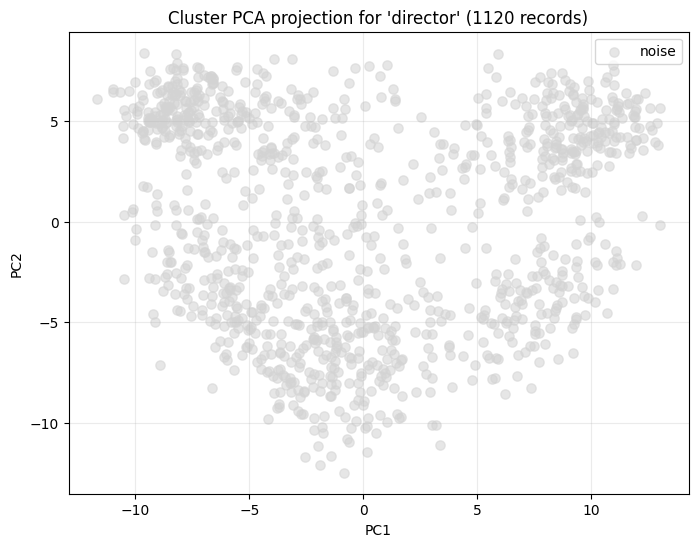

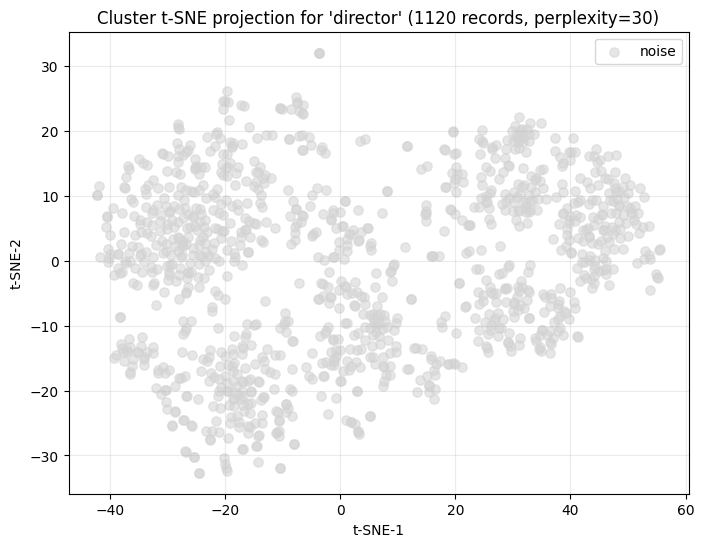

In [15]:
def cluster_span_embeddings(store, span_text, kind=None, merge_chunks=False, sample_limit=3, perplexity=30, random_state=42, annotate=False):
    records = lookup_embeddings(store, span_text, kind=kind, include_text=True, include_cleaned_text=True)

    if not records:
        print(f"No records found for {span_text!r}")
        return None

    if len(records) < 2:
        print(f"Only {len(records)} embedding found for {span_text!r}; at least 2 are required for clustering.")
        return {
            "query_text": span_text,
            "kind": kind,
            "records": records,
            "n_clusters": 0,
            "clusters": {},
            "cluster_centers": {},
        }

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    min_cluster_size = max(2, (len(records) + 9) // 10)
    embeds_list = [(torch.as_tensor(record["embedding"]), None) for record in records]
    n_clusters, clusters, cluster_centers = hdbscan_cluster(
        embeds_list,
        min_cluster_size=min_cluster_size,
        merge_chunks=merge_chunks,
    )

    print(f"Span: {span_text!r}")
    print(f"kind filter: {kind}")
    print(f"embedding count: {len(records)}")
    print(f"merge_chunks: {merge_chunks}")
    print(f"min_cluster_size: {min_cluster_size}")
    print(f"cluster count: {n_clusters}")

    sorted_clusters = sorted(clusters.items(), key=lambda item: (-len(item[1]), item[0]))
    for label, indices in sorted_clusters:
        cluster_name = "noise" if label == -1 else f"cluster {label}"
        print(f"{cluster_name}: {len(indices)} samples")

        for preview_idx, record_idx in enumerate(indices[:sample_limit], start=1):
            record = records[record_idx]
            start_char, end_char = record["span"]
            cleaned_text = record.get("cleaned_text", "")
            matched_text = cleaned_text[start_char:end_char] if cleaned_text else record["term"]
            context_start = max(0, start_char - 60)
            context_end = min(len(cleaned_text), end_char + 60)
            context = cleaned_text[context_start:context_end].replace("\n", " ").strip()
            print(f"  sample {preview_idx}: kind={record['kind']} | title={record['title']} | matched={matched_text!r}")
            if context:
                print(f"    context: {context}")

    cluster_records = []
    for label, indices in clusters.items():
        for record_idx in indices:
            item = dict(records[record_idx])
            item["cluster_label"] = label
            cluster_records.append(item)

    if len(cluster_records) >= 2:
        ordered_embeddings = np.stack([record["embedding"] for record in cluster_records]).astype(np.float32)
        normalized_query = normalize_text(span_text.strip())

        pca_coords = PCA(n_components=2).fit_transform(ordered_embeddings)
        _scatter_by_cluster(
            pca_coords,
            cluster_records,
            title=f"Cluster PCA projection for '{normalized_query}' ({len(cluster_records)} records)",
            xlabel="PC1",
            ylabel="PC2",
            annotate=annotate,
        )

        tsne_perplexity = min(perplexity, len(cluster_records) - 1)
        tsne_coords = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state,
        ).fit_transform(ordered_embeddings)
        _scatter_by_cluster(
            tsne_coords,
            cluster_records,
            title=f"Cluster t-SNE projection for '{normalized_query}' ({len(cluster_records)} records, perplexity={tsne_perplexity})",
            xlabel="t-SNE-1",
            ylabel="t-SNE-2",
            annotate=annotate,
        )
    else:
        pca_coords = None
        tsne_coords = None

    return {
        "query_text": span_text,
        "kind": kind,
        "records": records,
        "cluster_records": cluster_records,
        "embeddings": embeddings,
        "n_clusters": n_clusters,
        "clusters": dict(clusters),
        "cluster_centers": cluster_centers,
        "min_cluster_size": min_cluster_size,
        "pca_coords": pca_coords,
        "tsne_coords": tsne_coords,
    }


cluster_result = cluster_span_embeddings(embedding_store, "director", kind=None, merge_chunks=False, sample_limit=3)

In [12]:
def _ensure_document_record_index(store, verbose=True):
    if "_document_record_index" in store:
        if verbose:
            print(f"Using cached in-memory document record index for {len(store['_document_record_index'])} documents")
        return store["_document_record_index"]

    if verbose:
        print("Building in-memory document record index from existing embedding_store...")

    document_record_index = defaultdict(list)
    for term_records in store["index"].values():
        for record in term_records:
            document_record_index[record["document_idx"]].append(record)

    store["_document_record_index"] = dict(document_record_index)

    if verbose:
        print(f"Cached document record index for {len(store['_document_record_index'])} documents")

    return store["_document_record_index"]


def _build_cooccurrence_example(store, record):
    document_idx = record["document_idx"]
    cleaned_text = store["cleaned_documents"][document_idx]
    raw_text = store["documents"][document_idx]["text"]
    start_char, end_char = record["span"]
    context_start = max(0, start_char - 90)
    context_end = min(len(cleaned_text), end_char + 90)
    context = cleaned_text[context_start:context_end].replace("\n", " ").strip()
    matched_text = cleaned_text[start_char:end_char] if cleaned_text else record["term"]
    return {
        "title": record["title"],
        "document_idx": document_idx,
        "kind": record["kind"],
        "term": record["term"],
        "span": record["span"],
        "matched_text": matched_text,
        "context": context,
        "full_text": raw_text,
    }


def _format_cooccurring_spans_text(result, limit=None):
    lines = [
        f"Span: {result['query_text']!r}",
        f"query kind filter: {result['query_kind']}",
        f"co-occurring kind filter: {result['cooccur_kind']}",
        f"matched records: {len(result['query_records'])}",
        f"matched documents: {len(result['matched_document_indices'])}",
        f"unique co-occurring spans: {len(result['ranked_items'])}",
    ]

    display_items = result["ranked_items"] if limit is None else result["ranked_items"][:limit]
    lines.append(f"Showing {len(display_items)} entries sorted by document_count then occurrence_count")

    for rank, item in enumerate(display_items, start=1):
        lines.append(
            f"{rank:>4}. {item['term']} [{item['kind']}] | docs={item['document_count']} | occurrences={item['occurrence_count']}"
        )
        for example in item["examples"]:
            lines.append(
                f"      doc={example['title']} | document_idx={example['document_idx']} | span={example['span']} | matched={example['matched_text']!r}"
            )
            lines.append(f"         context: {example['context']}")

    return "\n".join(lines)


def _build_cooccurring_spans_html(result, limit=None, open_details=False):
    display_items = result["ranked_items"] if limit is None else result["ranked_items"][:limit]
    html_parts = ["<div style='font-family:Arial, sans-serif; line-height:1.5;'>"]
    html_parts.append(
        "<div style='margin-bottom:12px; padding:10px 12px; background:#f3f6f9; border:1px solid #d8e0e8; border-radius:8px;'>"
        f"<div><strong>Span:</strong> {escape(str(result['query_text']))}</div>"
        f"<div><strong>Matched records:</strong> {len(result['query_records'])} | <strong>Matched documents:</strong> {len(result['matched_document_indices'])} | <strong>Unique co-occurring spans:</strong> {len(result['ranked_items'])}</div>"
        f"<div><strong>query kind filter:</strong> {escape(str(result['query_kind']))} | <strong>co-occurring kind filter:</strong> {escape(str(result['cooccur_kind']))}</div>"
        "</div>"
    )

    for rank, item in enumerate(display_items, start=1):
        summary = f"{rank}. {item['term']} [{item['kind']}]"
        meta = f"docs={item['document_count']} | occurrences={item['occurrence_count']} | displayed_examples={len(item['examples'])}"
        html_parts.append(
            "<details style='margin:10px 0; border:1px solid #ddd; border-radius:8px; padding:8px 12px; background:#fafafa;' "
            f"{'open' if open_details else ''}>"
            f"<summary style='cursor:pointer; font-weight:700;'>{escape(summary)}</summary>"
            f"<div style='margin:6px 0 0 2px; font-size:12px; color:#666;'>{escape(meta)}</div>"
        )

        for example in item["examples"]:
            example_meta = (
                f"doc={example['title']} | document_idx={example['document_idx']} | "
                f"span={example['span']} | matched={example['matched_text']}"
            )
            html_parts.append(
                "<div style='margin:10px 0 6px 16px; padding:8px 10px; border-left:4px solid #4c78a8; background:#fff;'>"
                f"<div style='font-size:12px; color:#666; margin-bottom:4px;'>{escape(example_meta)}</div>"
                f"<div style='white-space:pre-wrap; margin-bottom:6px;'>{escape(example['context'])}</div>"
                "<details style='margin-top:6px;'>"
                "<summary style='cursor:pointer;'>Show full document text</summary>"
                f"<div style='white-space:pre-wrap; margin-top:6px;'>{escape(example['full_text'])}</div>"
                "</details>"
                "</div>"
            )

        html_parts.append("</details>")

    html_parts.append("</div>")
    return "".join(html_parts)


def print_cooccurring_spans(store, span_text, query_kind=None, cooccur_kind=None, limit=50, sample_limit=3, as_html=True, open_details=False):
    query_records = lookup_embeddings(store, span_text, kind=query_kind, include_text=True, include_cleaned_text=True)

    if not query_records:
        print(f"No records found for {span_text!r}")
        return None

    query_term = normalize_text(span_text.strip())
    matched_document_indices = sorted({record["document_idx"] for record in query_records})
    document_record_index = _ensure_document_record_index(store)

    cooccurrence_stats = {}

    for document_idx in matched_document_indices:
        document_records = document_record_index.get(document_idx, [])
        seen_in_document = set()

        for record in document_records:
            if record["term"] == query_term:
                continue
            if cooccur_kind is not None and record["kind"] != cooccur_kind:
                continue

            key = (record["term"], record["kind"])
            if key not in cooccurrence_stats:
                cooccurrence_stats[key] = {
                    "term": record["term"],
                    "kind": record["kind"],
                    "document_count": 0,
                    "occurrence_count": 0,
                    "examples": [],
                    "_seen_examples": set(),
                }

            item = cooccurrence_stats[key]
            item["occurrence_count"] += 1

            example_key = (record["document_idx"], tuple(record["span"]))
            if len(item["examples"]) < sample_limit and example_key not in item["_seen_examples"]:
                item["examples"].append(_build_cooccurrence_example(store, record))
                item["_seen_examples"].add(example_key)

            if key not in seen_in_document:
                item["document_count"] += 1
                seen_in_document.add(key)

    ranked_items = sorted(
        cooccurrence_stats.values(),
        key=lambda item: (-item["document_count"], -item["occurrence_count"], item["term"], item["kind"]),
    )

    for item in cooccurrence_stats.values():
        item.pop("_seen_examples", None)

    result = {
        "query_text": span_text,
        "query_kind": query_kind,
        "cooccur_kind": cooccur_kind,
        "query_records": query_records,
        "matched_document_indices": matched_document_indices,
        "ranked_items": ranked_items,
    }

    if as_html:
        display(HTML(_build_cooccurring_spans_html(result, limit=limit, open_details=open_details)))
    else:
        print(_format_cooccurring_spans_text(result, limit=limit))

    return result


cooccurrence_result = print_cooccurring_spans(embedding_store, "director", query_kind=None, cooccur_kind=None, limit=30, sample_limit=3, as_html=True, open_details=False)


Using cached in-memory document record index for 66581 documents


In [14]:
def _collect_cooccurring_span_stats_from_query_records(store, query_records, query_term, cooccur_kind=None, sample_limit=3):
    document_record_index = _ensure_document_record_index(store, verbose=False)
    matched_document_indices = sorted({record["document_idx"] for record in query_records})
    cooccurrence_stats = {}
    total_occurrence_count = 0

    for document_idx in matched_document_indices:
        document_records = document_record_index.get(document_idx, [])
        seen_in_document = set()

        for record in document_records:
            if record["term"] == query_term:
                continue
            if cooccur_kind is not None and record["kind"] != cooccur_kind:
                continue

            key = (record["term"], record["kind"])
            if key not in cooccurrence_stats:
                cooccurrence_stats[key] = {
                    "term": record["term"],
                    "kind": record["kind"],
                    "document_count": 0,
                    "occurrence_count": 0,
                    "probability": 0.0,
                    "examples": [],
                    "_seen_examples": set(),
                }

            item = cooccurrence_stats[key]
            item["occurrence_count"] += 1
            total_occurrence_count += 1

            example_key = (record["document_idx"], tuple(record["span"]))
            if len(item["examples"]) < sample_limit and example_key not in item["_seen_examples"]:
                item["examples"].append(_build_cooccurrence_example(store, record))
                item["_seen_examples"].add(example_key)

            if key not in seen_in_document:
                item["document_count"] += 1
                seen_in_document.add(key)

    for item in cooccurrence_stats.values():
        if total_occurrence_count > 0:
            item["probability"] = item["occurrence_count"] / total_occurrence_count
        item.pop("_seen_examples", None)

    ranked_items = sorted(
        cooccurrence_stats.values(),
        key=lambda item: (-item["occurrence_count"], -item["probability"], item["term"], item["kind"]),
    )

    return {
        "query_term": query_term,
        "cooccur_kind": cooccur_kind,
        "query_record_count": len(query_records),
        "matched_document_indices": matched_document_indices,
        "total_occurrence_count": total_occurrence_count,
        "ranked_items": ranked_items,
    }


def _cluster_query_records_hdbscan(query_records, merge_chunks=False):
    if not query_records:
        return {
            "min_cluster_size": 0,
            "n_clusters": 0,
            "clusters": {},
            "cluster_centers": {},
        }

    if len(query_records) < 2:
        return {
            "min_cluster_size": 1,
            "n_clusters": 0,
            "clusters": {-1: list(range(len(query_records)))},
            "cluster_centers": {},
        }

    min_cluster_size = max(2, (len(query_records) + 9) // 10)
    embeds_list = [(torch.as_tensor(record["embedding"]), None) for record in query_records]
    n_clusters, clusters, cluster_centers = hdbscan_cluster(
        embeds_list,
        min_cluster_size=min_cluster_size,
        merge_chunks=merge_chunks,
    )

    return {
        "min_cluster_size": min_cluster_size,
        "n_clusters": n_clusters,
        "clusters": dict(clusters),
        "cluster_centers": cluster_centers,
    }


def _format_frequency_scope_text(title, scope_result, top_k=None):
    lines = [
        title,
        f"query_records={scope_result['query_record_count']} | matched_documents={len(scope_result['matched_document_indices'])} | total_cooccurring_occurrences={scope_result['total_occurrence_count']}",
    ]

    display_items = scope_result["ranked_items"] if top_k is None else scope_result["ranked_items"][:top_k]
    lines.append(f"showing_top_k={len(display_items)}")

    for rank, item in enumerate(display_items, start=1):
        lines.append(
            f"{rank:>4}. {item['term']} [{item['kind']}] | occurrences={item['occurrence_count']} | probability={item['probability']:.6f} | docs={item['document_count']}"
        )

    return "\n".join(lines)


def _build_frequency_scope_html(title, scope_result, top_k=None, open_details=False):
    display_items = scope_result["ranked_items"] if top_k is None else scope_result["ranked_items"][:top_k]
    html_parts = [
        "<details style='margin:10px 0; border:1px solid #ddd; border-radius:8px; padding:8px 12px; background:#fafafa;' "
        f"{'open' if open_details else ''}>",
        f"<summary style='cursor:pointer; font-weight:700;'>{escape(title)}</summary>",
        f"<div style='margin:6px 0 10px 2px; font-size:12px; color:#666;'>query_records={scope_result['query_record_count']} | matched_documents={len(scope_result['matched_document_indices'])} | total_cooccurring_occurrences={scope_result['total_occurrence_count']} | displayed_top_k={len(display_items)}</div>",
    ]

    if not display_items:
        html_parts.append("<div style='margin-left:8px; color:#666;'>No co-occurring spans found.</div>")
    else:
        for rank, item in enumerate(display_items, start=1):
            row_title = f"{rank}. {item['term']} [{item['kind']}]"
            row_meta = (
                f"occurrences={item['occurrence_count']} | probability={item['probability']:.6f} | docs={item['document_count']} | displayed_examples={len(item['examples'])}"
            )
            html_parts.append(
                "<details style='margin:8px 0 8px 8px; border:1px solid #e3e7eb; border-radius:8px; padding:6px 10px; background:#fff;'>"
                f"<summary style='cursor:pointer; font-weight:600;'>{escape(row_title)}</summary>"
                f"<div style='margin:4px 0 6px 2px; font-size:12px; color:#666;'>{escape(row_meta)}</div>"
            )

            for example in item["examples"]:
                example_meta = (
                    f"doc={example['title']} | document_idx={example['document_idx']} | span={example['span']} | matched={example['matched_text']}"
                )
                html_parts.append(
                    "<div style='margin:8px 0 10px 8px; padding:8px 10px; border-left:4px solid #4c78a8; background:#fff;'>"
                    f"<div style='font-size:12px; color:#666; margin-bottom:4px;'>{escape(example_meta)}</div>"
                    f"<div style='white-space:pre-wrap; margin-bottom:6px;'>{escape(example['context'])}</div>"
                    "<details style='margin-top:6px;'>"
                    "<summary style='cursor:pointer;'>Show full document text</summary>"
                    f"<div style='white-space:pre-wrap; margin-top:6px;'>{escape(example['full_text'])}</div>"
                    "</details>"
                    "</div>"
                )

            html_parts.append("</details>")

    html_parts.append("</details>")
    return "".join(html_parts)


def analyze_clustered_cooccurring_spans(store, span_text, query_kind=None, cooccur_kind=None, top_k=20, sample_limit=3, merge_chunks=False, as_html=True, open_details=False):
    query_records = lookup_embeddings(store, span_text, kind=query_kind, include_text=True, include_cleaned_text=True)

    if not query_records:
        print(f"No records found for {span_text!r}")
        return None

    query_term = normalize_text(span_text.strip())
    before_scope = _collect_cooccurring_span_stats_from_query_records(
        store,
        query_records,
        query_term=query_term,
        cooccur_kind=cooccur_kind,
        sample_limit=sample_limit,
    )

    cluster_result = _cluster_query_records_hdbscan(query_records, merge_chunks=merge_chunks)
    cluster_scopes = []

    for label, indices in sorted(cluster_result["clusters"].items(), key=lambda item: (-len(item[1]), item[0])):
        cluster_query_records = [query_records[idx] for idx in indices]
        scope_result = _collect_cooccurring_span_stats_from_query_records(
            store,
            cluster_query_records,
            query_term=query_term,
            cooccur_kind=cooccur_kind,
            sample_limit=sample_limit,
        )
        scope_result["cluster_label"] = label
        scope_result["cluster_name"] = "noise" if label == -1 else f"cluster {label}"
        cluster_scopes.append(scope_result)

    result = {
        "query_text": span_text,
        "query_kind": query_kind,
        "cooccur_kind": cooccur_kind,
        "top_k": top_k,
        "sample_limit": sample_limit,
        "merge_chunks": merge_chunks,
        "query_record_count": len(query_records),
        "min_cluster_size": cluster_result["min_cluster_size"],
        "n_clusters": cluster_result["n_clusters"],
        "cluster_count_including_noise": len(cluster_result["clusters"]),
        "before_scope": before_scope,
        "cluster_scopes": cluster_scopes,
    }

    if as_html:
        html_parts = [
            "<div style='font-family:Arial, sans-serif; line-height:1.5;'>",
            "<div style='margin-bottom:12px; padding:10px 12px; background:#f3f6f9; border:1px solid #d8e0e8; border-radius:8px;'>",
            f"<div><strong>Span:</strong> {escape(str(span_text))}</div>",
            f"<div><strong>query kind filter:</strong> {escape(str(query_kind))} | <strong>co-occurring kind filter:</strong> {escape(str(cooccur_kind))}</div>",
            f"<div><strong>query record count:</strong> {len(query_records)} | <strong>merge_chunks:</strong> {merge_chunks} | <strong>min_cluster_size:</strong> {cluster_result['min_cluster_size']}</div>",
            f"<div><strong>clusters from HDBSCAN:</strong> {cluster_result['n_clusters']} | <strong>clusters including noise:</strong> {len(cluster_result['clusters'])}</div>",
            "</div>",
            _build_frequency_scope_html("Before HDBSCAN: top-k co-occurring spans", before_scope, top_k=top_k, open_details=open_details),
        ]

        for scope_result in cluster_scopes:
            section_title = f"After HDBSCAN: {scope_result['cluster_name']} top-k co-occurring spans"
            html_parts.append(_build_frequency_scope_html(section_title, scope_result, top_k=top_k, open_details=open_details))

        html_parts.append("</div>")
        display(HTML("".join(html_parts)))
    else:
        print(f"Span: {span_text!r}")
        print(f"query kind filter: {query_kind}")
        print(f"co-occurring kind filter: {cooccur_kind}")
        print(f"query record count: {len(query_records)}")
        print(f"merge_chunks: {merge_chunks}")
        print(f"min_cluster_size: {cluster_result['min_cluster_size']}")
        print(f"clusters from HDBSCAN: {cluster_result['n_clusters']}")
        print(f"clusters including noise: {len(cluster_result['clusters'])}")
        print()
        print(_format_frequency_scope_text("Before HDBSCAN: top-k co-occurring spans", before_scope, top_k=top_k))

        for scope_result in cluster_scopes:
            print()
            print(_format_frequency_scope_text(f"After HDBSCAN: {scope_result['cluster_name']} top-k co-occurring spans", scope_result, top_k=top_k))

    return result


cluster_cooccurrence_analysis = analyze_clustered_cooccurring_spans(
    embedding_store,
    "director",
    query_kind=None,
    cooccur_kind=None,
    top_k=20,
    sample_limit=3,
    merge_chunks=False,
    as_html=True,
    open_details=False,
)


In [10]:
query = "United States"
records = lookup_embeddings(embedding_store, query)

print(f"query={query!r}, matches={len(records)}")

if records:
    first = records[0]
    print("kind:", first["kind"])
    print("document_idx:", first["document_idx"])
    print("title:", first["title"])
    print("span in cleaned text:", first["span"])
    print("embedding shape:", first["embedding"].shape)
    print("raw text preview:")
    print(first["text"][:500])

records[:2]

query='United States', matches=5255
kind: phrase
document_idx: 2
title: Woodson, Arkansas
span in cleaned text: (75, 92)
embedding shape: (1024,)
raw text preview:
Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United States.  Its population was 403 at the 2010 census.  It is part of the Little Rock–North Little Rock–Conway Metropolitan Statistical Area.  Woodson and its accompanying Woodson Lake and Wood Hollow are the namesake for Ed Wood Sr., a prominent plantation owner, trader, and businessman at the turn of the 20th century.  Woodson is adjacent to the Wood Plantation, the largest of the plantations own by Ed Wood Sr.


[{'kind': 'phrase',
  'term': 'united states',
  'document_idx': 2,
  'title': 'Woodson, Arkansas',
  'span': (75, 92),
  'embedding': array([ 0.19121654,  1.4984213 , -0.12560014, ...,  0.16169693,
         -1.97542   , -0.18631136], dtype=float32),
  'text': 'Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United States.  Its population was 403 at the 2010 census.  It is part of the Little Rock–North Little Rock–Conway Metropolitan Statistical Area.  Woodson and its accompanying Woodson Lake and Wood Hollow are the namesake for Ed Wood Sr., a prominent plantation owner, trader, and businessman at the turn of the 20th century.  Woodson is adjacent to the Wood Plantation, the largest of the plantations own by Ed Wood Sr.',
  'cleaned_text': 'woodson is a census-designated place (CDP) in Pulaski County, arkansas, in the United States. its population was 403 at the 2010 census. it is part of the Little Rock–north Little Rock–Conway Metropolitan Statistical 

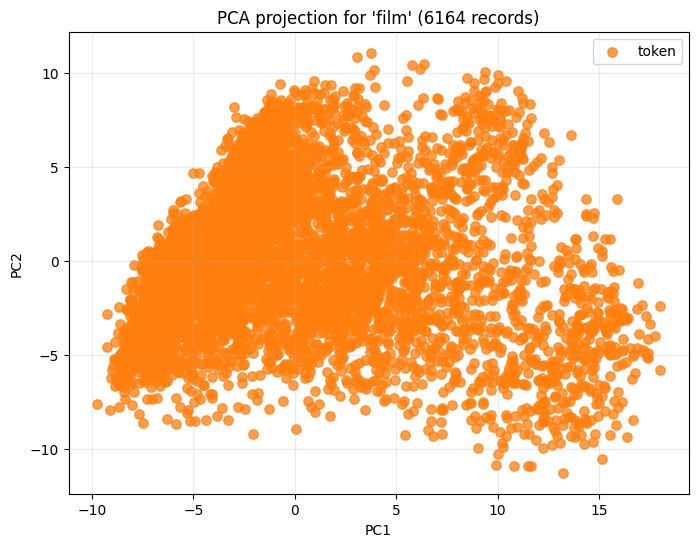

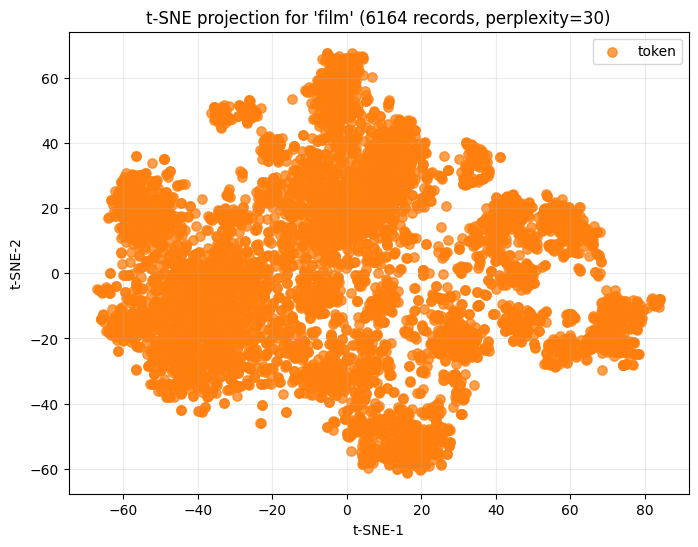

dict_keys(['records', 'embeddings', 'pca_coords', 'tsne_coords'])

In [11]:
plot_result = plot_term_embeddings(
    embedding_store,
    query_text="film",
    kind=None,
    perplexity=30,
    random_state=42,
    annotate=False,
)

plot_result.keys() if plot_result is not None else None